In [1]:
from pathlib import Path

PROJECT_ROOT = Path(r"A:\Coding\PycharmProjects\cryptoguard")
RESULTS_DIR  = PROJECT_ROOT / "outputs" / "results"
FIGURES_DIR  = PROJECT_ROOT / "outputs" / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Must match folder names in models/ and results/
MODEL_REGISTRY = [
    ("TF-IDF General",         "tfidf_general"),
    ("TF-IDF Blockchain",      "tfidf_blockchain"),
    ("DistilBERT General",     "distilbert_general"),
    ("BERT General",           "bert_general"),
    ("RoBERTa General",        "roberta_general"),
    ("DistilBERT Blockchain",  "distilbert_blockchain"),
    ("BERT Blockchain",        "bert_blockchain"),
    ("RoBERTa Blockchain",     "roberta_blockchain"),
]

ALPHA_LEVELS = {
    0.001: "***",
    0.01:  "**",
    0.05:  "*",
}

for display_name, folder in MODEL_REGISTRY:
    for test_set in ["general", "blockchain"]:
        path = RESULTS_DIR / folder / f"predictions_{test_set}.csv"
        print(f"{display_name:25s} [{test_set}]")

Verifying prediction files exist...
  ✓  TF-IDF General            [general]
  ✓  TF-IDF General            [blockchain]
  ✓  TF-IDF Blockchain         [general]
  ✓  TF-IDF Blockchain         [blockchain]
  ✓  DistilBERT General        [general]
  ✓  DistilBERT General        [blockchain]
  ✓  BERT General              [general]
  ✓  BERT General              [blockchain]
  ✓  RoBERTa General           [general]
  ✓  RoBERTa General           [blockchain]
  ✓  DistilBERT Blockchain     [general]
  ✓  DistilBERT Blockchain     [blockchain]
  ✓  BERT Blockchain           [general]
  ✓  BERT Blockchain           [blockchain]
  ✓  RoBERTa Blockchain        [general]
  ✓  RoBERTa Blockchain        [blockchain]


In [2]:
import numpy as np
import pandas as pd
import json
import itertools
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.stats import chi2

Imports loaded.


In [4]:
def mcnemar_test(y_true, y_pred_a, y_pred_b):
    """
    McNemar's test comparing two classifiers on the same test set.

    Contingency table:
        b = A correct, B wrong
        c = A wrong,   B correct

    Uses mid-p correction: chi2 = (|b - c| - 1)^2 / (b + c)
    Returns (chi2_stat, p_value, b, c)
    """
    correct_a = (y_pred_a == y_true)
    correct_b = (y_pred_b == y_true)

    b = np.sum( correct_a & ~correct_b)   # A right, B wrong
    c = np.sum(~correct_a &  correct_b)   # A wrong, B right

    if (b + c) == 0:
        return 0.0, 1.0, int(b), int(c)

    chi2_stat = (abs(b - c) - 1) ** 2 / (b + c)
    p_value   = 1 - chi2.cdf(chi2_stat, df=1)

    return float(chi2_stat), float(p_value), int(b), int(c)


def significance_stars(p):
    for threshold, stars in sorted(ALPHA_LEVELS.items()):
        if p < threshold:
            return stars
    return "not significant"

McNemar test function loaded.


In [5]:
predictions = {}   # {folder: {test_set: (y_true, y_pred)}}

for display_name, folder in MODEL_REGISTRY:
    predictions[folder] = {}
    for test_set in ["general", "blockchain"]:
        path = RESULTS_DIR / folder / f"predictions_{test_set}.csv"
        df   = pd.read_csv(path)
        predictions[folder][test_set] = (
            df['y_true'].values,
            df['y_pred'].values,
        )

for test_set in ["general", "blockchain"]:
    lengths = [len(predictions[f][test_set][0]) for _, f in MODEL_REGISTRY]
    assert len(set(lengths)) == 1, f"Test set lengths mismatch for {test_set}: {lengths}"
    print(f"  {test_set:10s} test set: {lengths[0]} samples per model")

Loaded predictions for 8 models × 2 test sets
  general    test set: 1600 samples per model ✓
  blockchain test set: 796 samples per model ✓


In [6]:
model_names   = [m[0] for m in MODEL_REGISTRY]
model_folders = [m[1] for m in MODEL_REGISTRY]
n_models      = len(MODEL_REGISTRY)
pairs         = list(itertools.combinations(range(n_models), 2))

print(f"Testing {len(pairs)} model pairs × 2 test sets = {len(pairs)*2} tests")
print()

# Storage: matrices for p-values and chi2 stats
results_by_testset = {}
all_test_records   = []

for test_set in ["general", "blockchain"]:
    p_matrix    = np.ones((n_models, n_models))
    chi2_matrix = np.zeros((n_models, n_models))

    print(f"Test set: {test_set.upper()}")
    print(f"{'Model A':25s}  {'Model B':25s}  {'b':>5}  {'c':>5}  "
          f"{'chi2':>7}  {'p':>8}  {'sig':>4}")

    for i, j in pairs:
        folder_a = model_folders[i]
        folder_b = model_folders[j]

        y_true   = predictions[folder_a][test_set][0]
        y_pred_a = predictions[folder_a][test_set][1]
        y_pred_b = predictions[folder_b][test_set][1]

        chi2_stat, p_val, b, c = mcnemar_test(y_true, y_pred_a, y_pred_b)
        stars = significance_stars(p_val)

        p_matrix[i, j]    = p_val
        p_matrix[j, i]    = p_val
        chi2_matrix[i, j] = chi2_stat
        chi2_matrix[j, i] = chi2_stat

        print(f"{model_names[i]:25s}  {model_names[j]:25s}  "
              f"{b:>5}  {c:>5}  {chi2_stat:>7.2f}  {p_val:>8.4f}  {stars:>4}")

        all_test_records.append({
            "test_set":  test_set,
            "model_a":   model_names[i],
            "model_b":   model_names[j],
            "b":         b,
            "c":         c,
            "chi2":      round(chi2_stat, 4),
            "p_value":   round(p_val, 6),
            "stars":     stars,
        })

    results_by_testset[test_set] = {
        "p_matrix":    p_matrix,
        "chi2_matrix": chi2_matrix,
    }
    print()

print("\n*** = p<0.001   ** = p<0.01   * = p<0.05   ns = not significant")

Testing 28 model pairs × 2 test sets = 56 tests

Test set: GENERAL
Model A                    Model B                        b      c     chi2         p   sig
-------------------------------------------------------------------------------------
TF-IDF General             TF-IDF Blockchain            784     13   743.91    0.0000   ***
TF-IDF General             DistilBERT General             8     22     5.63    0.0176     *
TF-IDF General             BERT General                   3     22    12.96    0.0003   ***
TF-IDF General             RoBERTa General                5     24    11.17    0.0008   ***
TF-IDF General             DistilBERT Blockchain         62     21    19.28    0.0000   ***
TF-IDF General             BERT Blockchain               37     22     3.32    0.0684    ns
TF-IDF General             RoBERTa Blockchain            25     23     0.02    0.8852    ns
TF-IDF Blockchain          DistilBERT General             7    792   769.28    0.0000   ***
TF-IDF Blockchain  

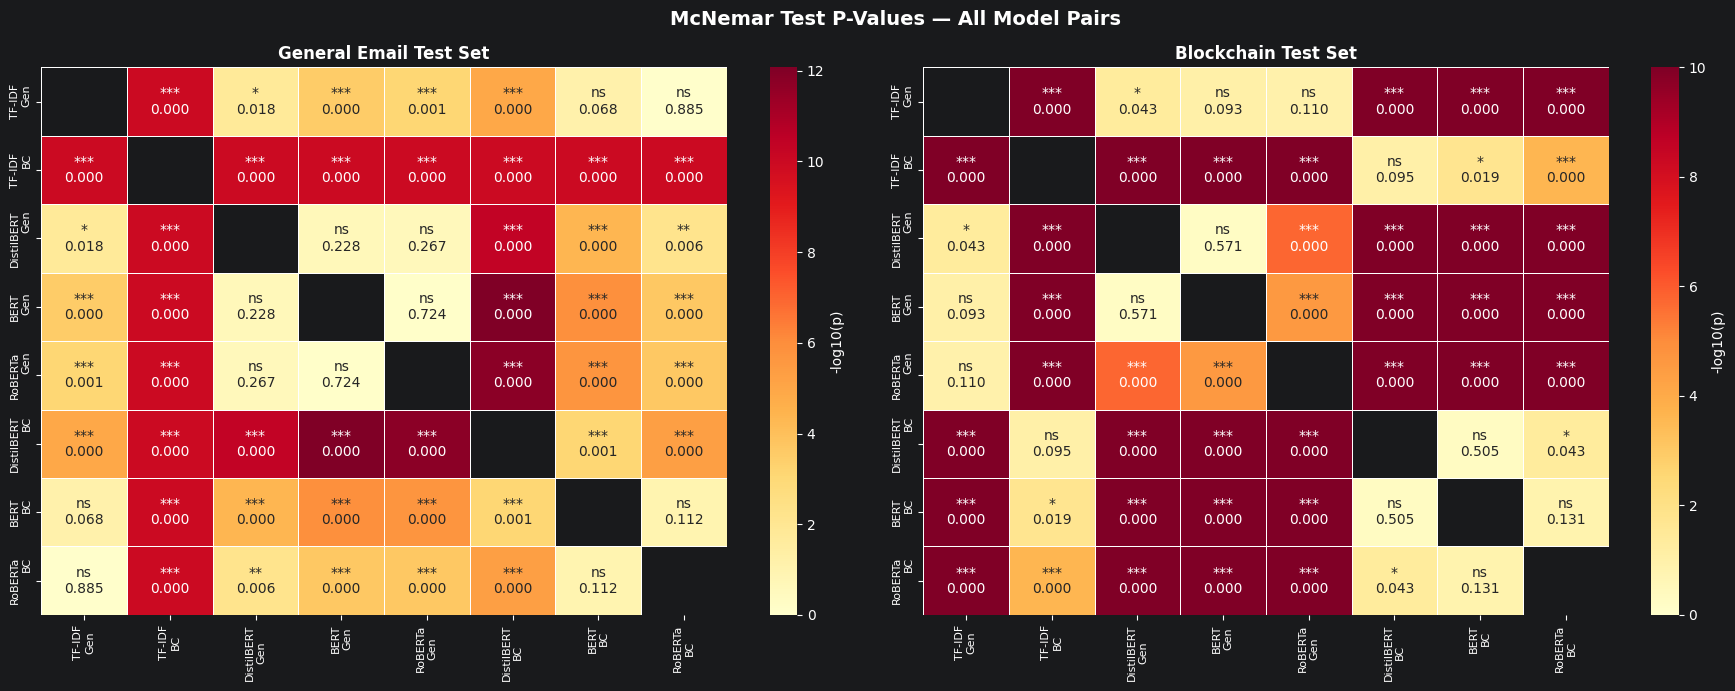

✓  Saved: A:\Coding\PycharmProjects\cryptoguard\outputs\figures\mcnemar_pvalue_heatmap.png


In [7]:
short_labels = [
    "TF-IDF\nGen",    "TF-IDF\nBC",
    "DistilBERT\nGen", "BERT\nGen",  "RoBERTa\nGen",
    "DistilBERT\nBC",  "BERT\nBC",   "RoBERTa\nBC",
]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("McNemar Test P-Values — All Model Pairs",
             fontsize=14, fontweight='bold')

for ax, test_set, panel_title in zip(
    axes,
    ["general", "blockchain"],
    ["General Email Test Set", "Blockchain Test Set"],
):
    p_mat = results_by_testset[test_set]["p_matrix"].copy()

    np.fill_diagonal(p_mat, np.nan)

    with np.errstate(divide='ignore'):
        log_p = -np.log10(np.where(p_mat == 0, 1e-10, p_mat))
    np.fill_diagonal(log_p, np.nan)

    annot = np.full((n_models, n_models), "", dtype=object)
    for i in range(n_models):
        for j in range(n_models):
            if i == j:
                annot[i, j] = "—"
            else:
                p   = p_mat[i, j]
                sig = significance_stars(p)
                annot[i, j] = f"{sig}\n{p:.3f}" if sig != "ns" else f"ns\n{p:.3f}"

    sns.heatmap(
        log_p,
        ax=ax,
        cmap="YlOrRd",
        xticklabels=short_labels,
        yticklabels=short_labels,
        annot=annot,
        fmt="",
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "-log10(p)"},
        vmin=0,
    )
    ax.set_title(panel_title, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
path = FIGURES_DIR / "mcnemar_pvalue_heatmap.png"
plt.savefig(str(path), dpi=150, bbox_inches='tight')
plt.show()

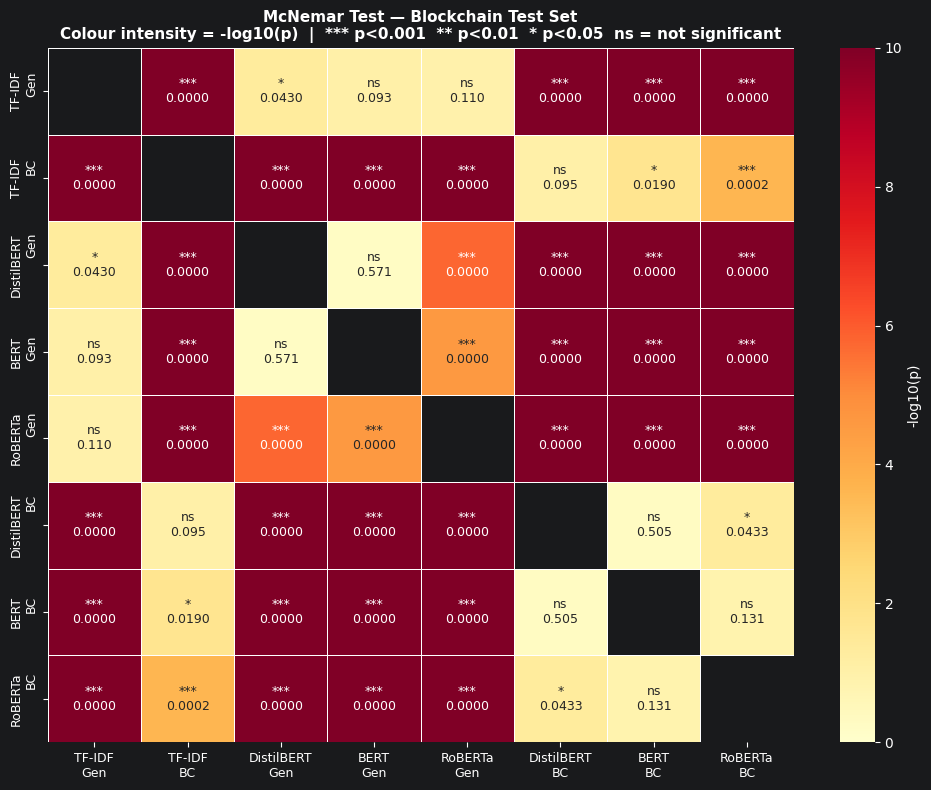

✓  Saved: A:\Coding\PycharmProjects\cryptoguard\outputs\figures\mcnemar_blockchain_heatmap.png


In [8]:
p_mat = results_by_testset["blockchain"]["p_matrix"].copy()
np.fill_diagonal(p_mat, np.nan)

with np.errstate(divide='ignore'):
    log_p = -np.log10(np.where(p_mat == 0, 1e-10, p_mat))
np.fill_diagonal(log_p, np.nan)

annot = np.full((n_models, n_models), "", dtype=object)
for i in range(n_models):
    for j in range(n_models):
        if i == j:
            annot[i, j] = "—"
        else:
            p   = p_mat[i, j]
            sig = significance_stars(p)
            annot[i, j] = f"{sig}\n{p:.4f}" if sig != "ns" else f"ns\n{p:.3f}"

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    log_p,
    ax=ax,
    cmap="YlOrRd",
    xticklabels=short_labels,
    yticklabels=short_labels,
    annot=annot,
    fmt="",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "-log10(p)"},
    vmin=0,
    annot_kws={"size": 9},
)
ax.set_title("McNemar Test — Blockchain Test Set\n"
             "Colour intensity = -log10(p)  |  *** p<0.001  ** p<0.01  * p<0.05  ns = not significant",
             fontsize=11, fontweight='bold')
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
path = FIGURES_DIR / "mcnemar_blockchain_heatmap.png"
plt.savefig(str(path), dpi=150, bbox_inches='tight')
plt.show()

In [9]:
KEY_PAIRS = [
    ("DistilBERT General",  "DistilBERT Blockchain"),
    ("BERT General",        "BERT Blockchain"),
    ("RoBERTa General",     "RoBERTa Blockchain"),
    ("TF-IDF General",      "RoBERTa Blockchain"),
    ("TF-IDF General",      "BERT Blockchain"),
    ("TF-IDF General",      "DistilBERT Blockchain"),
    ("DistilBERT Blockchain", "BERT Blockchain"),
    ("DistilBERT Blockchain", "RoBERTa Blockchain"),
    ("BERT Blockchain",       "RoBERTa Blockchain"),
]

name_to_idx = {name: i for i, (name, _) in enumerate(MODEL_REGISTRY)}

for test_set in ["general", "blockchain"]:
    p_mat = results_by_testset[test_set]["p_matrix"]
    print(f"\nKey comparisons [{test_set} test set] ")
    print(f"{'Model A':25s}  {'Model B':25s}  {'p-value':>10}  {'sig':>4}")
    print("-" * 70)
    for name_a, name_b in KEY_PAIRS:
        if name_a not in name_to_idx or name_b not in name_to_idx:
            continue
        i, j  = name_to_idx[name_a], name_to_idx[name_b]
        p_val = p_mat[i, j]
        stars = significance_stars(p_val)
        print(f"{name_a:25s}  {name_b:25s}  {p_val:>10.6f}  {stars:>4}")


── Key comparisons [GENERAL test set] ─────────────────────
Model A                    Model B                       p-value   sig
----------------------------------------------------------------------
DistilBERT General         DistilBERT Blockchain        0.000000   ***
BERT General               BERT Blockchain              0.000001   ***
RoBERTa General            RoBERTa Blockchain           0.000204   ***
TF-IDF General             RoBERTa Blockchain           0.885234    ns
TF-IDF General             BERT Blockchain              0.068357    ns
TF-IDF General             DistilBERT Blockchain        0.000011   ***
DistilBERT Blockchain      BERT Blockchain              0.000835   ***
DistilBERT Blockchain      RoBERTa Blockchain           0.000005   ***
BERT Blockchain            RoBERTa Blockchain           0.111961    ns

── Key comparisons [BLOCKCHAIN test set] ─────────────────────
Model A                    Model B                       p-value   sig
-----------------------

In [10]:
df_tests = pd.DataFrame(all_test_records)

csv_path  = RESULTS_DIR / "mcnemar_results.csv"
json_path = RESULTS_DIR / "mcnemar_results.json"

df_tests.to_csv(csv_path, index=False)
with open(json_path, "w") as f:
    json.dump(all_test_records, f, indent=2)

#significance summary
for test_set in ["general", "blockchain"]:
    subset = df_tests[df_tests['test_set'] == test_set]
    print(f"\n{test_set.upper()} test set — {len(subset)} pairs:")
    print(f"  ***  (p<0.001): {(subset['stars'] == '***').sum()}")
    print(f"  **   (p<0.01) : {(subset['stars'] == '**').sum()}")
    print(f"  *    (p<0.05) : {(subset['stars'] == '*').sum()}")
    print(f"  ns            : {(subset['stars'] == 'ns').sum()}")

✓  Saved: A:\Coding\PycharmProjects\cryptoguard\outputs\results\mcnemar_results.csv
✓  Saved: A:\Coding\PycharmProjects\cryptoguard\outputs\results\mcnemar_results.json

GENERAL test set — 28 pairs:
  ***  (p<0.001): 20
  **   (p<0.01) : 1
  *    (p<0.05) : 1
  ns            : 6

BLOCKCHAIN test set — 28 pairs:
  ***  (p<0.001): 19
  **   (p<0.01) : 0
  *    (p<0.05) : 3
  ns            : 6

STATISTICAL TESTING COMPLETE
Figures → A:\Coding\PycharmProjects\cryptoguard\outputs\figures
Results → A:\Coding\PycharmProjects\cryptoguard\outputs\results
Next    → 11_cross_validation.ipynb
